# Cosmological model-independent constraints on the baryon fraction in the IGM from fast radio bursts and supernovae data


The goal is to constrain the fraction of baryonic mass in the intergalactic medium, $f_{\rm IGM}$, without assuming a cosmological model. The method combines two datasets:
- **16 localised FRBs** whose dispersion measures trace the electron column density along the line of sight
- **1048 Pantheon SNe Ia** whose distance moduli provide $d_L(z)$ via a Gaussian Process reconstruction

By writing $\mathrm{DM}_{\rm IGM}$ directly in terms of $d_L(z)$, the Hubble parameter $H(z)$ drops out and the analysis becomes model-independent. Two parameterisations of $f_{\rm IGM}$ are considered: a **constant** case and a **time-dependent** case.

## **1. DATA PROCESSING**

### FRBs

In [6]:
import pandas as pd
import numpy as np

# ---------------------------------------------------------------------------
# 1. Raw data from Table 1
# ---------------------------------------------------------------------------
frb_data = {
    "Name": [
        "FRB180916B", "FRB201124A", "FRB190608B", "FRB200430A", "FRB121102A",
        "FRB191001A",  "FRB190714A", "FRB20191228A","FRB190102C", "FRB180924B",
        "FRB20180301A","FRB20200906A","FRB190611B", "FRB181112A", "FRB190711A",
        "FRB190523A",
    ],
    "z": [
        0.0337, 0.098,  0.1178, 0.16,   0.19273,
        0.234,  0.2365, 0.2432, 0.291,  0.3214,
        0.3305, 0.3688, 0.378,  0.4755, 0.522,
        0.66,
    ],
    "DM_MW_ISM": [
        200.0, 123.2,  37.2, 27.0, 188.0,
         44.7,  38.0,  33.0, 57.3,  40.5,
        152.0,  36.0,  57.83,102.0,  56.4,
         37.0,
    ],
    "DM_obs": [
        348.8,  413.52, 338.7,  380.25, 557.0,
        506.92, 504.13, 297.5,  363.6,  361.42,
        536.0,  577.8,  321.4,  589.27, 593.1,
        760.8,
    ],
    "sigma_obs": [
        0.2, 0.5, 0.5, 0.4, 2.0,
        0.04, 2.0, 0.05, 0.3, 0.06,
        8.0, 0.02, 0.2, 0.03, 0.4,
        0.6,
    ],
}

df = pd.DataFrame(frb_data)
df.head()

,Name,z,DM_MW_ISM,DM_obs,sigma_obs
0,FRB180916B,0.03370,200.0,348.80,0.2
1,FRB201124A,0.09800,123.2,413.52,0.5
2,FRB190608B,0.11780,37.2,338.70,0.5
3,FRB200430A,0.16000,27.0,380.25,0.4
4,FRB121102A,0.19273,188.0,557.00,2.0


In [7]:
# ---------------------------------------------------------------------------
# 2. Derived quantities
# ---------------------------------------------------------------------------
DM_MW_HALO = 50.0   # pc cm^-3
SIGMA_MW   = 10.0   # pc cm^-3

df["DM_MW_halo"] = DM_MW_HALO
df["DM_MW"]      = df["DM_MW_ISM"] + DM_MW_HALO
df["DM_ext"]     = df["DM_obs"]    - df["DM_MW"]
df["sigma_MW"]   = SIGMA_MW
df["DM_ext_err"] = np.sqrt(df["sigma_obs"] ** 2 + SIGMA_MW ** 2)

DM_ext     = df["DM_ext"].values
z_frb      = df["z"].values
DM_ext_err = df["DM_ext_err"].values

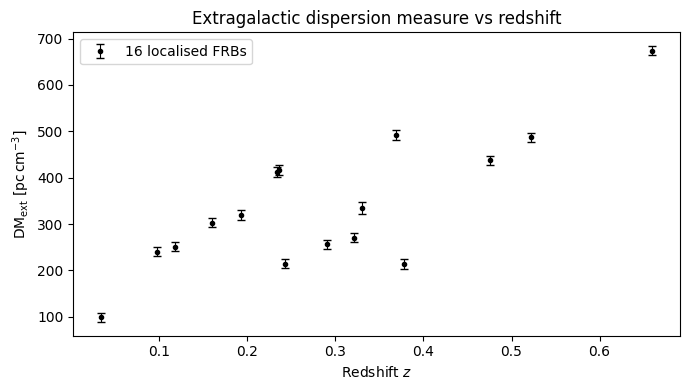

In [8]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 4))
ax.errorbar(z_frb, DM_ext, yerr=DM_ext_err,
            fmt='.k', capsize=3, elinewidth=0.8, label="16 localised FRBs")
ax.set_xlabel(r"Redshift $z$")
ax.set_ylabel(r"$\mathrm{DM}_{\rm ext}\ [\mathrm{pc\,cm^{-3}}]$")
ax.legend()
ax.set_title("Extragalactic dispersion measure vs redshift")
plt.tight_layout()
plt.show()

### Pantheon SN data

In [9]:
!wget https://raw.githubusercontent.com/rrnto/FRB-SN-cosmology/092a169565abcbfd310d72cc767defda7c29019b/lcparam_full_long.txt -q

In [10]:
sn = pd.read_csv("lcparam_full_long.txt", delimiter=' ')
sn.head()

,#name,zcmb,zhel,dz,mb,dmb,x1,dx1,color,dcolor,3rdvar,d3rdvar,cov_m_s,cov_m_c,cov_s_c,set,ra,dec,biascor,Unnamed: 19
0,03D1au,0.50309,0.50309,0.0,22.93445,0.12605,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN
1,03D1ax,0.49480,0.49480,0.0,22.88020,0.11765,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN
2,03D1co,0.67767,0.67767,0.0,24.03770,0.20560,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN
3,03D1ew,0.86650,0.86650,0.0,24.34685,0.17385,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN
4,03D1fq,0.79857,0.79857,0.0,24.36050,0.17435,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN


In [11]:
# Sort the sn dataset by redshift
sn_sorted = sn.sort_values(by="zcmb").reset_index(drop=True)

MB       = -19.214
sigma_MB = 0.037

mu_sorted = sn_sorted["mb"] - MB
sigma_mu  = np.sqrt(sn_sorted["dmb"].values**2 + sigma_MB**2)

print(f"Pantheon SNe: {len(sn_sorted)} events, z ∈ [{sn_sorted['zcmb'].min():.3f}, {sn_sorted['zcmb'].max():.3f}]")
sn_sorted.head()

Pantheon SNe: 1048 events, z ∈ [0.010, 2.260]


,#name,zcmb,zhel,dz,mb,dmb,x1,dx1,color,dcolor,3rdvar,d3rdvar,cov_m_s,cov_m_c,cov_s_c,set,ra,dec,biascor,Unnamed: 19
0,2002cr,0.01012,0.01012,0.0,13.90745,0.19825,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN
1,2002dp,0.01038,0.01038,0.0,14.04960,0.20480,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN
2,2009an,0.01043,0.01043,0.0,13.92480,0.20035,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN
3,2006bh,0.01082,0.01082,0.0,14.00860,0.18445,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN
4,1998dk,0.01209,0.01209,0.0,13.97910,0.19140,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN


### Gaussian Process reconstruction of $d_L(z)$

A Gaussian Process is fitted to the Pantheon distance moduli $\mu(z)$ to obtain a smooth, model-independent reconstruction. The luminosity distance follows from

$$
d_L(z) = 10^{\,(\mu(z) - 25)\,/\,5} \quad [\mathrm{Mpc}].
$$

The GP will be queried at the FRB redshifts to evaluate the integral in the DM model.

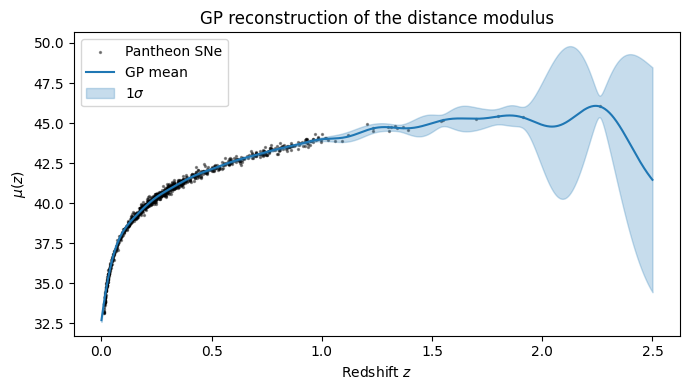

In [12]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel

X    = sn_sorted["zcmb"].values[:, np.newaxis]
y_mu = mu_sorted.values

kernel = ConstantKernel(1.0, (1e-2, 1e2)) * RBF(
    length_scale=0.5, length_scale_bounds=(0.05, 5.0)
)
gp_mu = GaussianProcessRegressor(
    kernel=kernel, alpha=sigma_mu**2,
    normalize_y=True, n_restarts_optimizer=10
)
gp_mu.fit(X, y_mu)

X_pred          = np.linspace(0, 2.5, 1000)[:, np.newaxis]
y_pred_mu, s_mu = gp_mu.predict(X_pred, return_std=True)

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(X, y_mu, c='k', s=2, alpha=0.4, label="Pantheon SNe")
ax.plot(X_pred, y_pred_mu, 'C0', lw=1.5, label="GP mean")
ax.fill_between(X_pred.flatten(),
                y_pred_mu - s_mu, y_pred_mu + s_mu,
                alpha=0.25, color='C0', label=r"$1\sigma$")
ax.set_xlabel(r"Redshift $z$")
ax.set_ylabel(r"$\mu(z)$")
ax.set_title("GP reconstruction of the distance modulus")
ax.legend()
plt.tight_layout()
plt.show()

In [13]:
def mu_of_z(z):
    z = np.atleast_1d(z)[:, np.newaxis]
    return gp_mu.predict(z, return_std=True)   # (mu, sigma)

def dL_of_z(z):
    mu, s    = mu_of_z(z)
    dL       = 10 ** ((mu - 25) / 5)
    sigma_dL = np.log(10) / 5 * dL * s
    return dL, sigma_dL

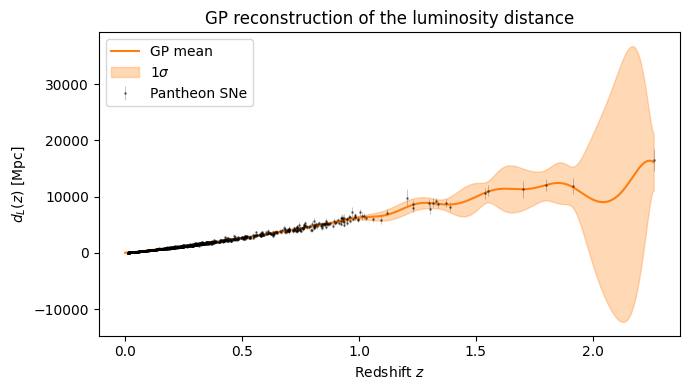

In [14]:
z_vis         = np.linspace(0, sn_sorted["zcmb"].max(), 500)
dL_vis, s_vis = dL_of_z(z_vis)
dL_obs        = 10 ** ((mu_sorted - 25) / 5)
s_dL_obs      = np.log(10) / 5 * dL_obs * sigma_mu

fig, ax = plt.subplots(figsize=(7, 4))
ax.errorbar(sn_sorted["zcmb"], dL_obs, yerr=s_dL_obs,
            fmt=".k", ms=2, elinewidth=0.4, capsize=0, alpha=0.4,
            label="Pantheon SNe")
ax.plot(z_vis, dL_vis, "C1", lw=1.5, label="GP mean")
ax.fill_between(z_vis,
                dL_vis.flatten() - s_vis.flatten(),
                dL_vis.flatten() + s_vis.flatten(),
                color="C1", alpha=0.3, label=r"$1\sigma$")
ax.set_xlabel(r"Redshift $z$")
ax.set_ylabel(r"$d_L(z)\ [\mathrm{Mpc}]$")
ax.set_title("GP reconstruction of the luminosity distance")
ax.legend()
plt.tight_layout()
plt.show()

## **2. MODEL**

The theoretical extragalactic DM is the sum of the IGM and host galaxy contributions:

$$
\mathrm{DM}_{\rm ext}^{\rm th}(z) = \mathrm{DM}_{\rm IGM}(z) + \mathrm{DM}_{\rm host}(z).
$$

The host DM is redshifted into the observer frame:

$$
\mathrm{DM}_{\rm host}(z) = \frac{\mathrm{DM}_{\rm host,0}}{1+z}.
$$

In [15]:
def DM_host(z, DM_host_0):
    return DM_host_0 / (1 + z)

The IGM contribution is given by (Eq. 5):

$$
\mathrm{DM}_{\rm IGM}(z)
  = A \int_0^z \frac{(1+z')\,f_{\rm IGM}(z')}{H(z')}\,dz',
\qquad
A = \frac{21\,c\,\Omega_b H_0^2}{64\pi G m_p}.
$$

By integrating by parts and substituting $d_L(z) = c(1+z)\int_0^z dz'/H(z')$, this becomes expressible purely in terms of $d_L(z)$, eliminating $H(z)$ entirely.

In [16]:
# Physical constants in SI
c    = 2.99792458e8               # m s^-1
G    = 6.67430e-11                # m^3 kg^-1 s^-2
mp   = 1.6726e-27                 # kg
H0   = 74.03e3 / 3.085677581e22  # s^-1
h    = 74.03 / 100
obh2 = 0.02235
om_b = obh2 / h**2

A = (21 * c * om_b * H0**2) / (64 * np.pi * G * mp)

Both parameterisations share the same integral (Eq. 12):

$$
\mathcal{I}(z_i) = \int_0^{z_i} \frac{d_L(z')}{c\,(1+z')}\,dz'
\approx \frac{1}{2c} \sum_{n=1}^N (z_{n+1} - z_n)
\left[ \frac{d_L(z_{n+1})}{1+z_{n+1}} + \frac{d_L(z_n)}{1+z_n} \right].
$$

Since $\mathcal{I}(z_i)$ and $d_L(z_i)$ depend only on the GP reconstruction and not on the free parameters, they are pre-computed once for all 16 FRB redshifts before the MCMC.

### Units — why no explicit conversion is needed

$$[\mathrm{DM}_{\mathrm{IGM}}(z)] = [A]\times\left[\frac{d_L}{c} - \mathcal{I}\right]$$

$$[\mathrm{DM}_{\mathrm{IGM}}(z)]
= \frac{\mathrm{m\,s^{-1}\cdot s^{-2}}}{\mathrm{m^3\,kg^{-1}\,s^{-2}\cdot kg}}
\times\frac{\mathrm{Mpc}}{\mathrm{m\,s^{-1}}}
= \frac{\mathrm{Mpc}}{\mathrm{m^{3}}}
= \frac{10^6\,\mathrm{pc}}{(10^2\,\mathrm{cm})^{3}}
= \frac{10^6\,\mathrm{pc}}{10^6\,\mathrm{cm^{3}}}$$

$$\boxed{[\mathrm{DM}_{\mathrm{IGM}}] = \mathrm{pc\,cm^{-3}}}$$

With $d_L$ returned in Mpc by the GP and all physical constants
($c$, $G$, $m_p$, $H_0$) kept in SI throughout, the mixed units
cancel algebraically to yield $\mathrm{pc\,cm^{-3}}$ — no explicit
conversion factor is needed in the code.

In [17]:
def solve_numerical_integral(z_grid, dL_grid):
    """
    Trapezoidal approximation of Eq. 12.
    z_grid : fine array from 0 to z_i
    dL_grid: GP luminosity distances in Mpc at z_grid
    """
    integrand = dL_grid / (1.0 + z_grid)
    delta_z   = np.diff(z_grid)
    return np.sum(delta_z * (integrand[:-1] + integrand[1:])) / (2 * c)


# Pre-compute dL(z_i) and I(z_i) for each FRB 
dL_frb = np.empty(len(z_frb))
I_frb  = np.empty(len(z_frb))

for k, zi in enumerate(z_frb):
    z_grid     = np.linspace(0.0, zi, 500)
    dL_grid, _ = dL_of_z(z_grid)
    dL_grid    = dL_grid.flatten()
    dL_frb[k]  = dL_grid[-1]
    I_frb[k]   = solve_numerical_integral(z_grid, dL_grid)

print("Pre-computation done.")
print(f"  dL range : {dL_frb.min():.1f} — {dL_frb.max():.1f} Mpc")
print(f"  I  range : {I_frb.min():.3e} — {I_frb.max():.3e} Mpc s / m")

Pre-computation done.
  dL range : 129.8 — 3719.6 Mpc
  I  range : 8.293e-09 — 2.633e-06 Mpc s / m


### Constant $f_{\rm IGM}$

$$f_{\rm IGM}(z) = f_{\rm IGM,0}$$

Substituting into the integrated form of Eq. 5 gives (Eq. 11):

$$
\mathrm{DM}_{\rm IGM}(z)
  = A\,f_{\rm IGM,0}
    \left[
      \frac{d_L(z)}{c} - \mathcal{I}(z)
    \right].
$$

Free parameters: $f_{\rm IGM,0}$, $\mathrm{DM}_{\rm host,0}$.

In [18]:
def DM_IGM_const(f_IGM_0):
    return A * f_IGM_0 * (dL_frb / c - I_frb)

### Time-dependent $f_{\rm IGM}$

$$f_{\rm IGM}(z) = f_{\rm IGM,0} + \alpha\,\frac{z}{1+z}$$

where $\alpha \geq 0$ allows for a growing baryon fraction with redshift. Substituting into Eq. 8 gives (Eq. 10):

$$
\mathrm{DM}_{\rm IGM}(z)
  = A\left(f_{\rm IGM,0} + \alpha\frac{z}{1+z}\right)\frac{d_L(z)}{c}
  - A\left(f_{\rm IGM,0} + \alpha\right)\mathcal{I}(z).
$$

Note that the same pre-computed $d_L(z_i)$ and $\mathcal{I}(z_i)$ are reused — no additional GP calls are needed.

Free parameters: $f_{\rm IGM,0}$, $\alpha$, $\mathrm{DM}_{\rm host,0}$.

In [19]:
def DM_IGM_timedep(f_IGM_0, alpha):
    f_at_z = f_IGM_0 + alpha * z_frb / (1.0 + z_frb)
    return A * (f_at_z * dL_frb / c - (f_IGM_0 + alpha) * I_frb)

### Unified theoretical model

In [20]:
def DM_ext_th(params, DM_IGM_model):
  DM_host_0 = params[-1]
  return DM_IGM_model(*params[:-1]) + DM_host(z_frb, DM_host_0)

## **3. BAYESIAN INFERENCE**

### Case A — Constant $f_{\rm IGM}$

In [21]:
def log_prior_const(params):
    f, D = params
    if 0.0 <= f <= 1 and 0.0 <= D <= 300.0:
        return 0.0
    return -np.inf

def log_prob_const(params):
    lp = log_prior_const(params)
    if not np.isfinite(lp):
        return -np.inf
    theory = DM_ext_th(params, DM_IGM_const)
    if np.any(~np.isfinite(theory)):
        return -np.inf
    return lp - 0.5 * np.sum(((DM_ext - theory) / DM_ext_err) ** 2)

In [22]:
!pip install emcee corner -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.4/47.4 kB 1.5 MB/s eta 0:00:00


In [23]:
## Run MCMC

import emcee
import corner

ndim_c, nwalkers_c, nsteps_c = 2, 32, 10000
rng = np.random.default_rng(42)
p0  = np.column_stack([
    rng.uniform(0.5,  1.0, nwalkers_c),
    rng.uniform(50., 250., nwalkers_c),
])

sampler_const = emcee.EnsembleSampler(nwalkers_c, ndim_c, log_prob_const)
sampler_const.run_mcmc(p0, nsteps_c, progress=True)

print(f"Mean acceptance fraction : {np.mean(sampler_const.acceptance_fraction):.3f}")
tau = sampler_const.get_autocorr_time()
print(f"Autocorrelation times    : f_IGM = {tau[0]:.0f} steps, DM_host = {tau[1]:.0f} steps")

100%|██████████| 10000/10000 [00:20<00:00, 491.83it/s]


Mean acceptance fraction : 0.712
Autocorrelation times    : f_IGM = 32 steps, DM_host = 31 steps


Autocorrelation times : [32.37009312 30.70609321]
Burn-in               : 64 steps
Thinning factor       : 15
Posterior samples     : 21184


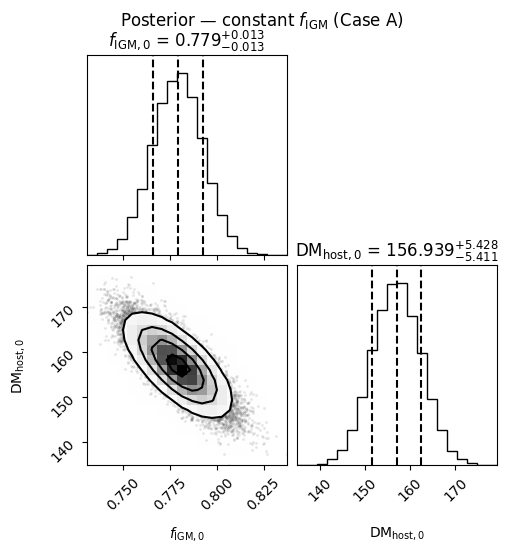


f_IGM,0   = 0.779 + 0.013 - 0.013
DM_host,0 = 156.939 + 5.428 - 5.411  pc/cm^3


In [24]:
tau     = sampler_const.get_autocorr_time()
burn_in = int(2 * np.max(tau))
thin    = max(1, int(np.min(tau) / 2))
print(f"Autocorrelation times : {tau}")
print(f"Burn-in               : {burn_in} steps")
print(f"Thinning factor       : {thin}")

flat_const = sampler_const.get_chain(discard=burn_in, thin=thin, flat=True)
print(f"Posterior samples     : {flat_const.shape[0]}")

fig = corner.corner(
    flat_const,
    labels=[r"$f_{\rm IGM,0}$", r"$\mathrm{DM}_{\rm host,0}$"],
    show_titles=True, title_fmt=".3f",
    quantiles=[0.16, 0.50, 0.84],
    smooth=1.0
)
plt.suptitle(r"Posterior — constant $f_{\rm IGM}$ (Case A)", y=1.01)
plt.show()

f_med, f_lo, f_hi = np.percentile(flat_const[:, 0], [50, 16, 84])
D_med, D_lo, D_hi = np.percentile(flat_const[:, 1], [50, 16, 84])
print(f"\nf_IGM,0   = {f_med:.3f} + {f_hi-f_med:.3f} - {f_med-f_lo:.3f}")
print(f"DM_host,0 = {D_med:.3f} + {D_hi-D_med:.3f} - {D_med-D_lo:.3f}  pc/cm^3")

### Case B — Time-dependent $f_{\rm IGM}$


In [25]:
def log_prior_timedep(params):
    f, a, D = params
    if 0.0 <= f <= 1.5 and 0.0 <= a <= 3 and 0.0 <= D <= 300.0:
        return 0.0
    return -np.inf

def log_prob_timedep(params):
    lp = log_prior_timedep(params)
    if not np.isfinite(lp):
        return -np.inf
    theory = DM_ext_th(params, DM_IGM_timedep)
    if np.any(~np.isfinite(theory)):
        return -np.inf
    return lp - 0.5 * np.sum(((DM_ext - theory) / DM_ext_err) ** 2)

In [26]:
ndim, nwalkers, nsteps = 3, 32, 10000
rng = np.random.default_rng(42)
p0  = np.column_stack([
    rng.uniform(0.3,  0.7, nwalkers),   # f_IGM_0
    rng.uniform(0.5,  2.0, nwalkers),   # alpha
    rng.uniform(50., 250., nwalkers),   # DM_host_0
])

sampler_timedep = emcee.EnsembleSampler(nwalkers, ndim, log_prob_timedep)
sampler_timedep.run_mcmc(p0, nsteps, progress=True)

print(f"Mean acceptance fraction : {np.mean(sampler_timedep.acceptance_fraction):.3f}")
tau = sampler_timedep.get_autocorr_time()
print(f"Autocorrelation times    : f_IGM_0 = {tau[0]:.0f}, alpha = {tau[1]:.0f}, DM_host = {tau[2]:.0f} steps")

100%|██████████| 10000/10000 [00:28<00:00, 345.37it/s]


Mean acceptance fraction : 0.643
Autocorrelation times    : f_IGM_0 = 40, alpha = 40, DM_host = 38 steps


Autocorrelation times : [39.59186744 39.51584809 37.75140021]
Burn-in               : 79 steps
Thinning factor       : 18
Posterior samples     : 17632


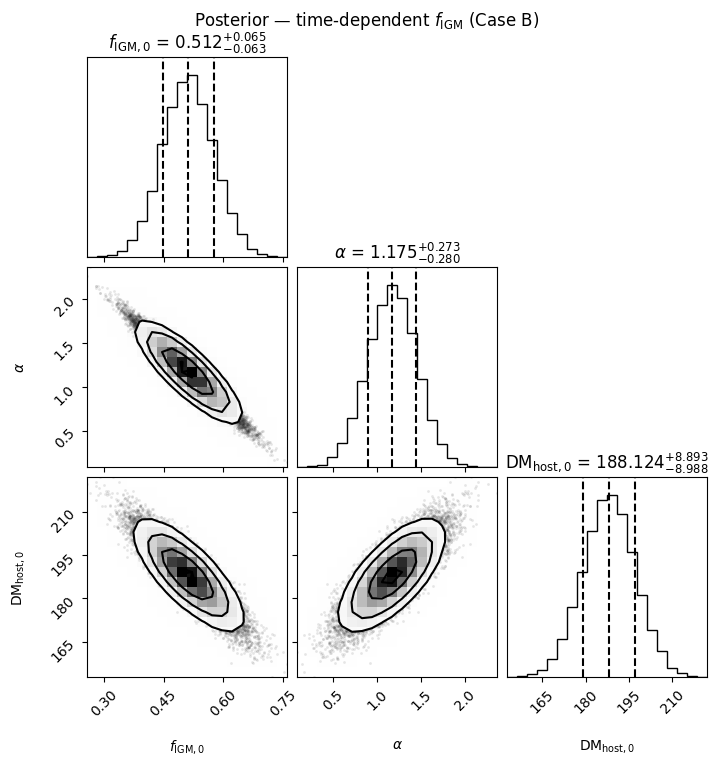


f_IGM,0   = 0.512 + 0.065 - 0.063
alpha     = 1.175 + 0.273 - 0.280
DM_host,0 = 188.1 + 8.9 - 9.0  pc/cm^3


In [27]:
tau     = sampler_timedep.get_autocorr_time()
burn_in = int(2 * np.max(tau))
thin    = max(1, int(np.min(tau) / 2))
print(f"Autocorrelation times : {tau}")
print(f"Burn-in               : {burn_in} steps")
print(f"Thinning factor       : {thin}")

flat_timedep = sampler_timedep.get_chain(discard=burn_in, thin=thin, flat=True)
print(f"Posterior samples     : {flat_timedep.shape[0]}")

fig = corner.corner(
    flat_timedep,
    labels=[r"$f_{\rm IGM,0}$", r"$\alpha$", r"$\mathrm{DM}_{\rm host,0}$"],
    show_titles=True, title_fmt=".3f",
    smooth=1.0,
    quantiles=[0.16, 0.50, 0.84],
)
plt.suptitle(r"Posterior — time-dependent $f_{\rm IGM}$ (Case B)", y=1.01)
plt.show()

f_med, f_lo, f_hi = np.percentile(flat_timedep[:, 0], [50, 16, 84])
a_med, a_lo, a_hi = np.percentile(flat_timedep[:, 1], [50, 16, 84])
D_med, D_lo, D_hi = np.percentile(flat_timedep[:, 2], [50, 16, 84])
print(f"\nf_IGM,0   = {f_med:.3f} + {f_hi-f_med:.3f} - {f_med-f_lo:.3f}")
print(f"alpha     = {a_med:.3f} + {a_hi-a_med:.3f} - {a_med-a_lo:.3f}")
print(f"DM_host,0 = {D_med:.1f} + {D_hi-D_med:.1f} - {D_med-D_lo:.1f}  pc/cm^3")

## **4. MODEL COMPARISON**

Nested sampling method computes the Bayesian evidence:

$$
\mathcal{Z} = P(D|M),
$$

which allows direct model comparison through:

$$
\Delta \ln \mathcal{Z}
=
\ln \mathcal{Z}_{\rm evolving}
-
\ln \mathcal{Z}_{\rm constant}.
$$

Interpretation:

| $\Delta \ln \mathcal{Z}$ | Interpretation |
|---|---|
| $<1$ | inconclusive |
| $1-3$ | weak evidence |
| $3-5$ | moderate evidence |
| $>5$ | strong evidence |

In [28]:
!pip install dynesty -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.9/102.9 kB 3.3 MB/s eta 0:00:00


### Case A — Constant $f_{\rm IGM}$

In [43]:

from dynesty import NestedSampler


def log_likelihood_const(params):
    theory = DM_ext_th(params, DM_IGM_const)
    if np.any(~np.isfinite(theory)):
        return -np.inf
    return -0.5 * np.sum(((DM_ext - theory) / DM_ext_err) ** 2)

def prior_transform_const(u):
    f_IGM_0_min, f_IGM_0_max = 0.0, 1.5
    DM_host_0_min, DM_host_0_max = 0.0, 300.0

    f_IGM_0 = u[0] * (f_IGM_0_max - f_IGM_0_min) + f_IGM_0_min
    DM_host_0 = u[1] * (DM_host_0_max - DM_host_0_min) + DM_host_0_min
    return [f_IGM_0, DM_host_0]


## initialize nested sampling
dynesty_const = NestedSampler(
    log_likelihood_const,
    prior_transform_const,
    ndim_c,
    nlive=1000
)
dynesty_const.run_nested()
results_const = dynesty_const.results


7768it [00:12, 613.20it/s, +1000 | bound: 7 | nc: 1 | ncall: 43587 | eff(%): 20.588 | loglstar:   -inf < -552.982 <    inf | logz: -560.503 +/-  0.081 | dlogz:  0.001 >  1.009]


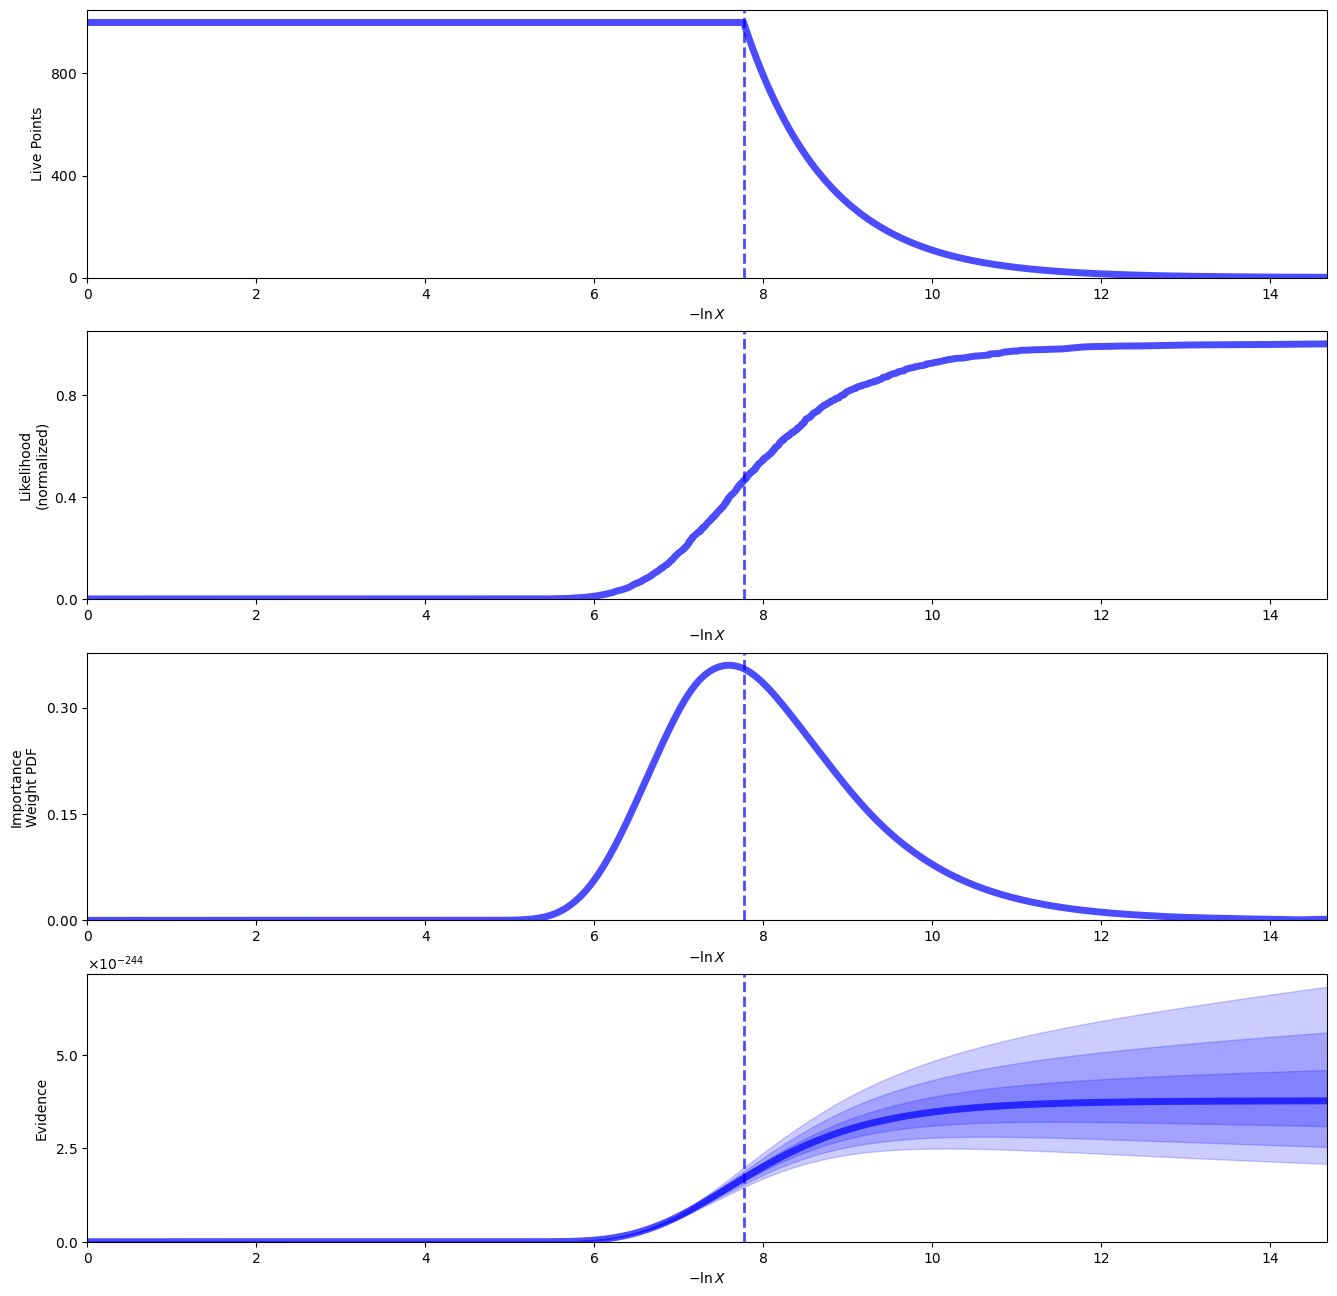

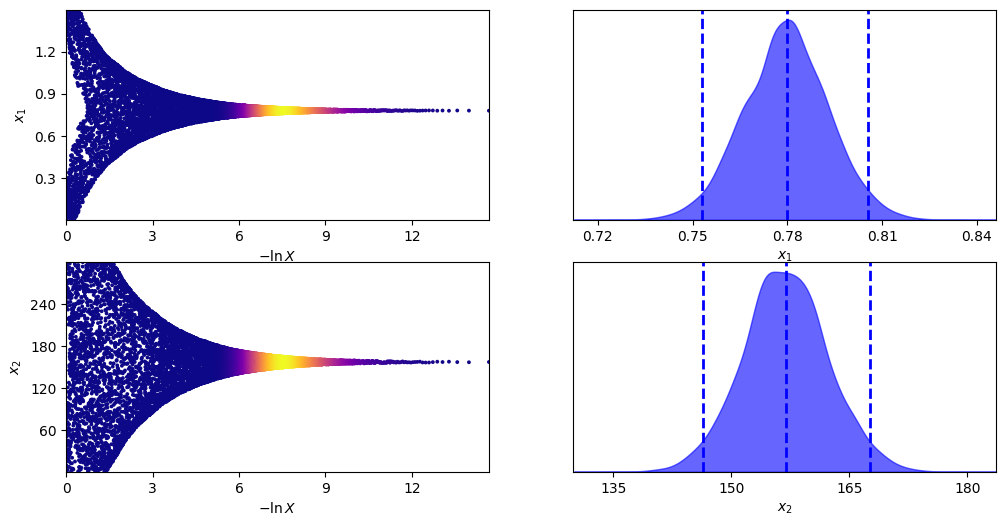

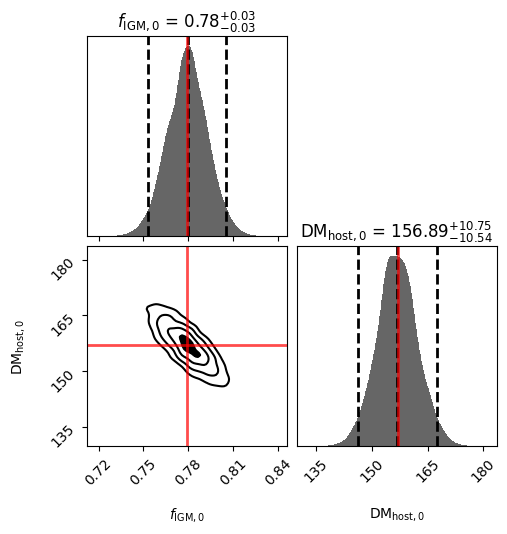

In [44]:
from dynesty import plotting as dyplot

rfig, raxes = dyplot.runplot(results_const)

tfig, taxes = dyplot.traceplot(results_const)


f_med_const = np.percentile(flat_const[:, 0], 50)
D_med_const = np.percentile(flat_const[:, 1], 50)

dffig, dfaxes = dyplot.cornerplot(results_const,
                                  labels=[r"$f_{\rm IGM,0}$", r"$\mathrm{DM}_{\rm host,0}$"],
                                  truths=[f_med_const, D_med_const],
                                  show_titles=True)

### Case B — Time-dependent $f_{\rm IGM}$

In [45]:
def log_likelihood_timedep(params):
    theory = DM_ext_th(params, DM_IGM_timedep)
    if np.any(~np.isfinite(theory)):
        return -np.inf
    return -0.5 * np.sum(((DM_ext - theory) / DM_ext_err) ** 2)

def prior_transform_timedep(u):
    f_IGM_0_min, f_IGM_0_max = 0.0, 1.5
    alpha_min, alpha_max = 0.0, 5.0 
    DM_host_0_min, DM_host_0_max = 0.0, 300.0

    f_IGM_0 = u[0] * (f_IGM_0_max - f_IGM_0_min) + f_IGM_0_min
    alpha = u[1] * (alpha_max - alpha_min) + alpha_min
    DM_host_0 = u[2] * (DM_host_0_max - DM_host_0_min) + DM_host_0_min
    return [f_IGM_0, alpha, DM_host_0]

In [46]:

# Initialize nested sampling for the time-dependent model
dynesty_timedep = NestedSampler(
    log_likelihood_timedep,
    prior_transform_timedep,
    ndim,
    nlive=1000
)
dynesty_timedep.run_nested()
results_timedep = dynesty_timedep.results

9637it [00:14, 657.61it/s, +1000 | bound: 11 | nc: 1 | ncall: 47881 | eff(%): 22.689 | loglstar:   -inf < -544.101 <    inf | logz: -553.635 +/-  0.101 | dlogz:  0.001 >  1.009]


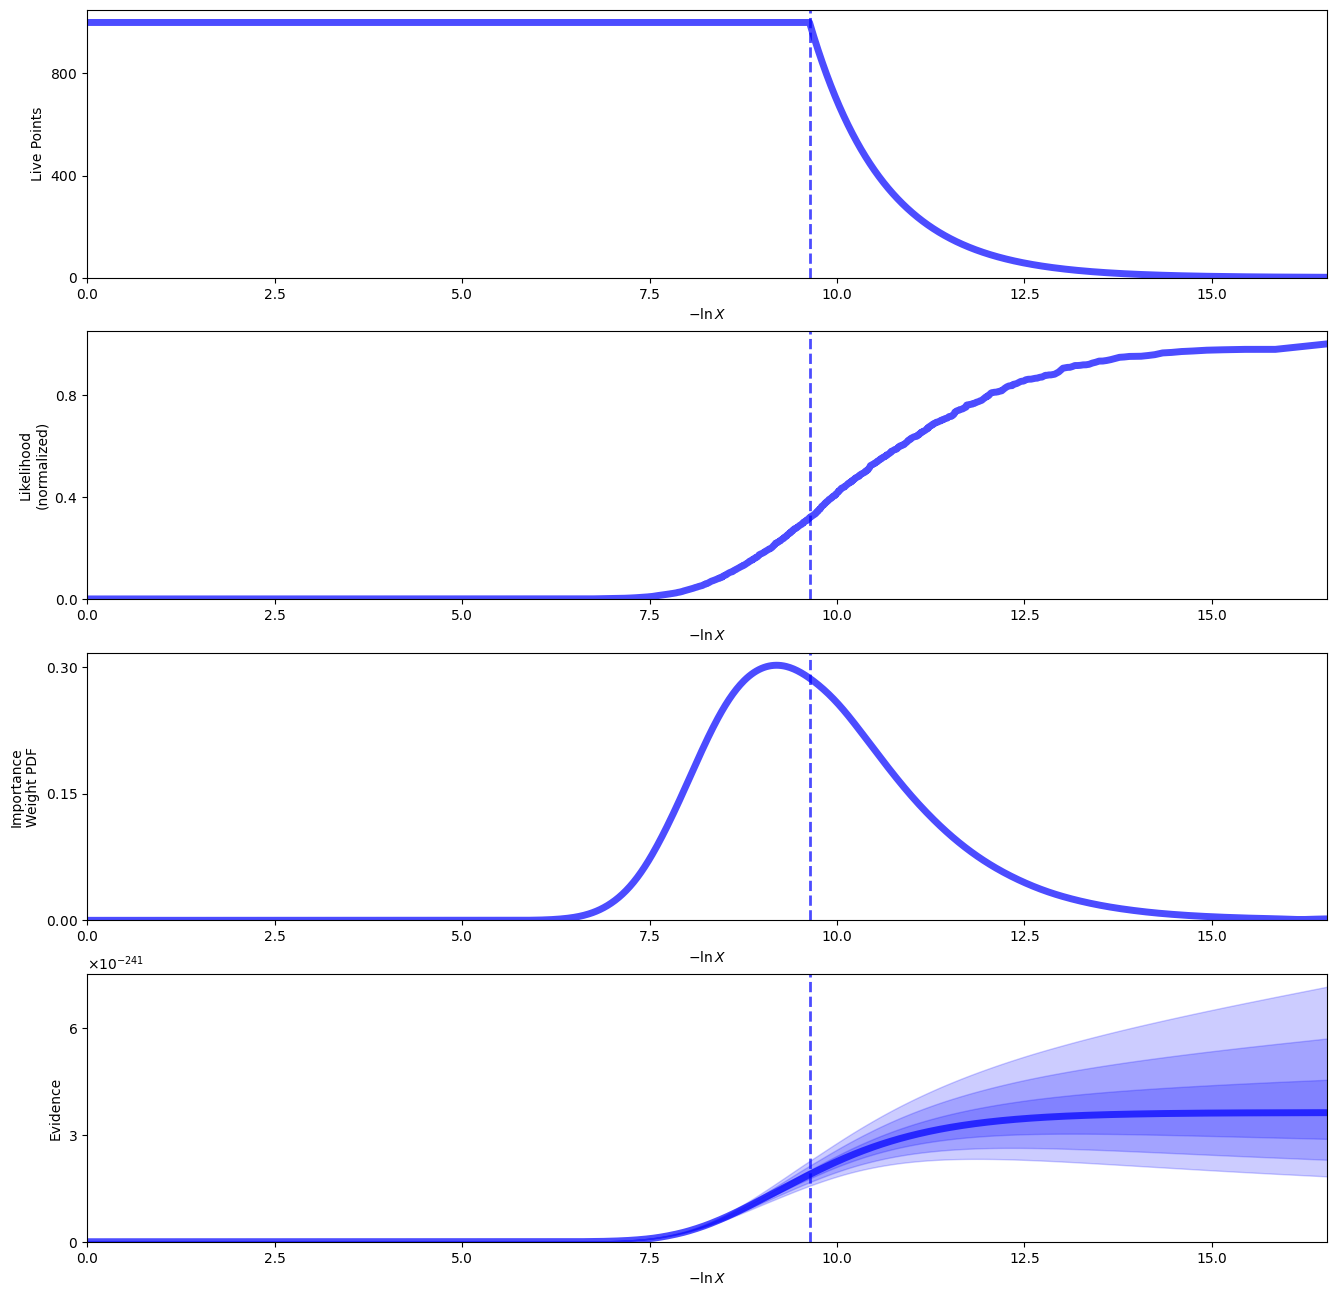

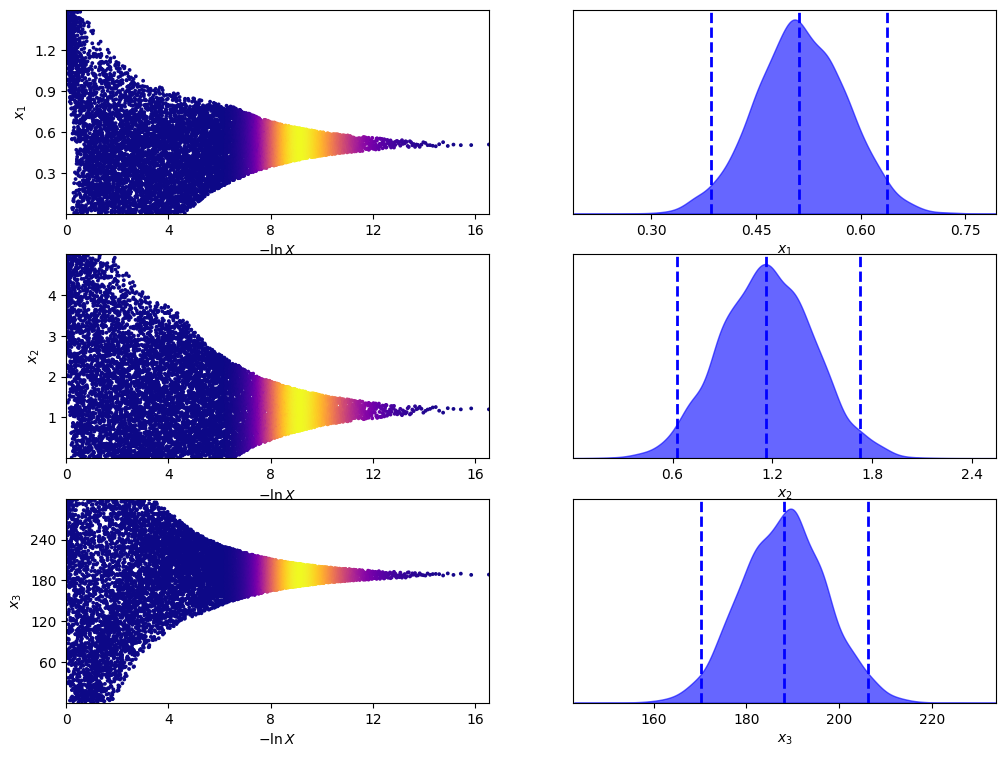

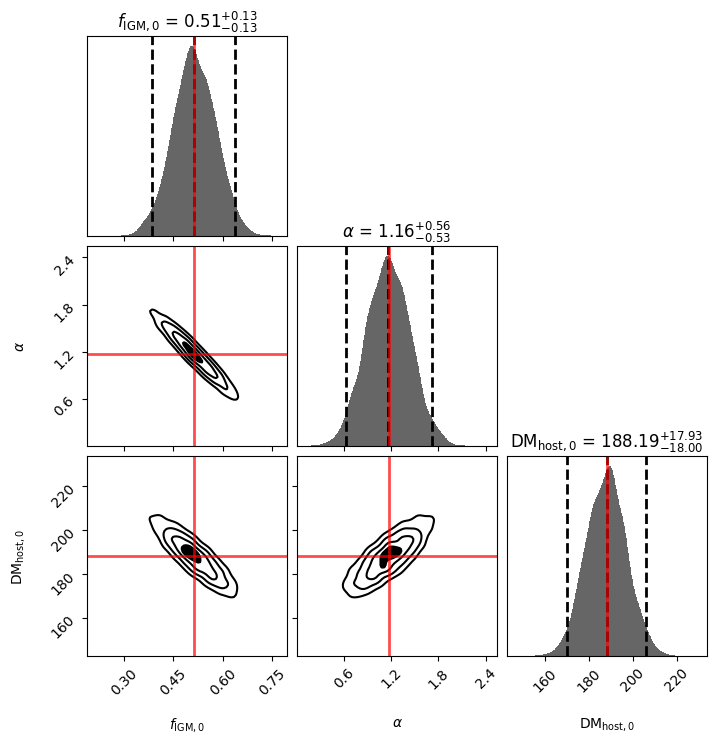

In [48]:
from dynesty import plotting as dyplot

rfig_timedep, raxes_timedep = dyplot.runplot(results_timedep)

tfig_timedep, taxes_timedep = dyplot.traceplot(results_timedep)


f_med_timedep = np.percentile(flat_timedep[:, 0], 50)
a_med_timedep = np.percentile(flat_timedep[:, 1], 50)
D_med_timedep = np.percentile(flat_timedep[:, 2], 50)

timedep_truths = [f_med_timedep, a_med_timedep, D_med_timedep]

dffig_timedep, dfaxes_timedep = dyplot.cornerplot(results_timedep,
                                                labels=[r"$f_{\rm IGM,0}$", r"$\alpha$", r"$\mathrm{DM}_{\rm host,0}$"],
                                                truths=timedep_truths,
                                                show_titles=True)

### Model Comparison Results

We compare the two models based on their Bayesian evidence values ($\mathcal{Z}$) calculated using `dynesty`. The difference in log-evidence $\Delta\, \ln\, \mathcal{Z}$ determines model preference via the Jeffreys scale.

In [50]:
# Extract log-evidence values and their uncertainties (using the final converged value)
logz_const = results_const.logz[-1]
logzerr_const = results_const.logzerr[-1]

logz_timedep = results_timedep.logz[-1]
logzerr_timedep = results_timedep.logzerr[-1]

# Calculate Delta ln Z
delta_ln_Z = logz_timedep - logz_const
delta_ln_Z_err = np.sqrt(logzerr_timedep**2 + logzerr_const**2)

print(f"Log-evidence for Constant f_IGM model (ln Z_const): {logz_const:.3f} +/- {logzerr_const:.3f}")
print(f"Log-evidence for Time-dependent f_IGM model (ln Z_timedep): {logz_timedep:.3f} +/- {logzerr_timedep:.3f}")
print(f"\nDelta ln Z (Time-dependent - Constant): {delta_ln_Z:.3f} +/- {delta_ln_Z_err:.3f}")

# Interpret using Jeffreys scale
print("\nInterpretation (Jeffreys' Scale):")
if delta_ln_Z < 1:
    print("  Inconclusive evidence in favor of the time-dependent model.")
elif 1 <= delta_ln_Z < 3:
    print("  Weak evidence in favor of the time-dependent model.")
elif 3 <= delta_ln_Z < 5:
    print("  Moderate evidence in favor of the time-dependent model.")
elif delta_ln_Z >= 5:
    print("  Strong evidence in favor of the time-dependent model.")
else:
    print("  The constant f_IGM model is preferred.")

Log-evidence for Constant f_IGM model (ln Z_const): -560.503 +/- 0.198
Log-evidence for Time-dependent f_IGM model (ln Z_timedep): -553.635 +/- 0.227

Delta ln Z (Time-dependent - Constant): 6.868 +/- 0.301

Interpretation (Jeffreys' Scale):
  Strong evidence in favor of the time-dependent model.


## **5. SAVING**

In [51]:
# ---------------------------------------------------------------------------
# 5.1  MOUNT GOOGLE DRIVE + SETUP
# ---------------------------------------------------------------------------
import os, json, datetime
import h5py
from google.colab import drive

drive.mount("/content/drive")

PROJECT_DIR  = "/content/drive/MyDrive/frb_cosmology_thesis"
CHAINS_DIR   = os.path.join(PROJECT_DIR, "chains")
EVIDENCE_DIR = os.path.join(PROJECT_DIR, "evidence")

os.makedirs(CHAINS_DIR,   exist_ok=True)
os.makedirs(EVIDENCE_DIR, exist_ok=True)

print("Project  →", PROJECT_DIR)
print("Chains   →", CHAINS_DIR)
print("Evidence →", EVIDENCE_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project  → /content/drive/MyDrive/frb_cosmology_thesis
Chains   → /content/drive/MyDrive/frb_cosmology_thesis/chains
Evidence → /content/drive/MyDrive/frb_cosmology_thesis/evidence


In [52]:
# ---------------------------------------------------------------------------
# 5.2  CASE A — constant f_IGM
# ---------------------------------------------------------------------------
with h5py.File(os.path.join(CHAINS_DIR, "model_independent_caseA.h5"), "w") as f:
    f.create_dataset("chain", data=flat_const)
    f.attrs["param_names"]  = ["f_IGM_0", "DM_host_0"]
    f.attrs["param_labels"] = [r"f_{\rm IGM,0}", r"\mathrm{DM}_{\rm host,0}"]
    f.attrs["logz"]         = float(logz_const)
    f.attrs["logzerr"]      = float(logzerr_const)
    f.attrs["note"]         = "burned-in and thinned emcee chain, model-independent Case A"

print("Saved: model_independent_caseA.h5")

Saved: model_independent_caseA.h5


In [53]:
# ---------------------------------------------------------------------------
# 5.3  CASE B — time-dependent f_IGM
# ---------------------------------------------------------------------------
with h5py.File(os.path.join(CHAINS_DIR, "model_independent_caseB.h5"), "w") as f:
    f.create_dataset("chain", data=flat_timedep)
    f.attrs["param_names"]  = ["f_IGM_0", "alpha", "DM_host_0"]
    f.attrs["param_labels"] = [r"f_{\rm IGM,0}", r"\alpha", r"\mathrm{DM}_{\rm host,0}"]
    f.attrs["logz"]         = float(logz_timedep)
    f.attrs["logzerr"]      = float(logzerr_timedep)
    f.attrs["note"]         = "burned-in and thinned emcee chain, model-independent Case B"

print("Saved: model_independent_caseB.h5")

Saved: model_independent_caseB.h5


In [54]:
# ---------------------------------------------------------------------------
# 5.4  BAYES EVIDENCE
# ---------------------------------------------------------------------------
entry = {
    "model_independent": {
        "case_A": {"logz": float(logz_const),   "logzerr": float(logzerr_const)},
        "case_B": {"logz": float(logz_timedep), "logzerr": float(logzerr_timedep)},
        "delta_lnZ_BvsA":     float(delta_ln_Z),
        "delta_lnZ_BvsA_err": float(delta_ln_Z_err),
    }
}

bayes_path = os.path.join(EVIDENCE_DIR, "bayes_evidence.json")
if os.path.exists(bayes_path):
    with open(bayes_path) as jf:
        existing = json.load(jf)
    existing.update(entry)
    entry = existing

with open(bayes_path, "w") as jf:
    json.dump(entry, jf, indent=2)

print("Saved: evidence/bayes_evidence.json")
print(json.dumps(entry, indent=2))

Saved: evidence/bayes_evidence.json
{
  "model_independent": {
    "case_A": {
      "logz": -560.5029264972775,
      "logzerr": 0.1978881268911515
    },
    "case_B": {
      "logz": -553.6351197594189,
      "logzerr": 0.22704803343448685
    },
    "delta_lnZ_BvsA": 6.8678067378585865,
    "delta_lnZ_BvsA_err": 0.30118187238105204
  }
}
